In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

## Load in the Dataset and Select the 10 Sports We Will Be Testing On

In [7]:
data_dir = "./archive (1)"  
transform = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
trainfull = datasets.ImageFolder(os.path.join(data_dir,"train"), transform=transform)
testfull  = datasets.ImageFolder(os.path.join(data_dir,"test"),  transform=transform)
print("All original classes:")
print(trainfull.classes)
selected_folders = ["air hockey","baseball","basketball","bowling","boxing","cricket","field hockey","football","swimming","tennis",]
classnames = selected_folders
print("\nSelected classes:", classnames)
selected_label_ids = {trainfull.class_to_idx[f] for f in selected_folders}
print("Selected label ids:", selected_label_ids)
trainindices= [i for i,(_, y) in enumerate(trainfull.samples)if y in selected_label_ids]
testindices= [i for i,(_, y) in enumerate(testfull.samples)if y in selected_label_ids]
traindata =Subset(trainfull, trainindices)
testdata  =Subset(testfull,  testindices)
train_loader= DataLoader(traindata, batch_size=64, shuffle=True)
test_loader =DataLoader(testdata,  batch_size=64, shuffle=False)
print("Train size:", len(traindata))
print("Test size:", len(testdata))

All original classes:
['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading', 'chuckwagon racing', 'cricket', 'croquet', 'curling', 'disc golf', 'fencing', 'field hockey', 'figure skating men', 'figure skating pairs', 'figure skating women', 'fly fishing', 'football', 'formula 1 racing', 'frisbee', 'gaga', 'giant slalom', 'golf', 'hammer throw', 'hang gliding', 'harness racing', 'high jump', 'hockey', 'horse jumping', 'horse racing', 'horseshoe pitching', 'hurdles', 'hydroplane racing', 'ice climbing', 'ice yachting', 'jai alai', 'javelin', 'jousting', 'judo', 'lacrosse', 'log rolling', 'luge', 'motorcycle racing', 'mushing', 'nascar racing', 'olympic wrestling', 'parallel bar', 'pole climbing', 'pole dancing', 'pole vault', 'polo', 'pommel horse', 'rings', 'ro

## Flattening Image Batches into Feature Vectors 

In [10]:
def flatten_loader(l):
    """Flatten all image batches into numpy arrays X and y"""
    Xs = []
    ys = []
    for a, b in l:
        n = a.shape[0]
        f = a.numpy().reshape(n, -1)
        Xs.append(f)
        ys.append(b.numpy())
    X = np.vstack(Xs)
    y = np.hstack(ys)
    return X, y
X_train, y_train = flatten_loader(train_loader)
X_test, y_test = flatten_loader(test_loader)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1456, 12288)
Test: (50, 12288)


## PCA + Logistic Regression

## Plotting the PCA Cumulative Explained Variance Curve

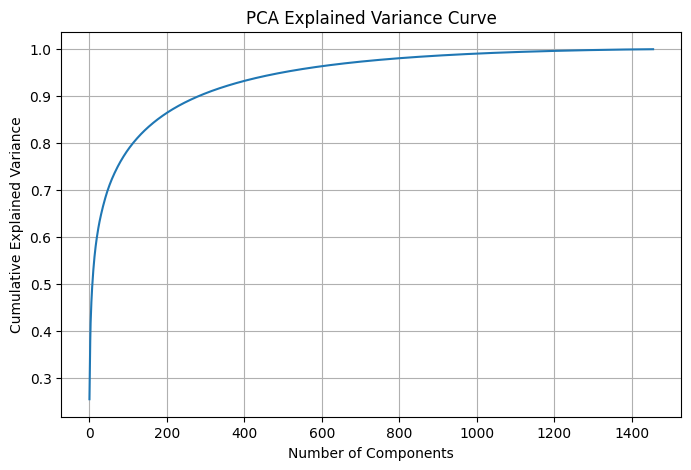

In [13]:
pca_full=PCA().fit(X_train)
explainedvar=pca_full.explained_variance_ratio_
cumvar=np.cumsum(explainedvar)
plt.figure(figsize=(8, 5))
plt.plot(cumvar)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Curve")
plt.grid(True)
plt.show()

## Identifying optimal PCA component values for model testing

In [15]:
def find_k(threshold):
    """Return the smallest k such that cumulative variance is greater than the threshold"""
    return int(np.argmax(cumvar>= threshold)+1)
k90=find_k(0.90)
k95= find_k(0.95)
k99= find_k(0.99)
print("k for 90% variance:", k90)
print("k for 95% variance:", k95)
print("k for 99% variance:", k99)
k_values = sorted(list({30, 50, 75,           
    k90, k95, k99,max(5, k90 - 50), k90 + 50,
    max(5, k95 - 50), k95 + 50,max(5, k99 - 100), k99 + 100}))
print("k values to test:", k_values)

k for 90% variance: 283
k for 95% variance: 497
k for 99% variance: 983
k values to test: [30, 50, 75, 233, 283, 333, 447, 497, 547, 883, 983, 1083]


## Logistic regression classification across different PCA values of k

In [17]:
ks = [30, 50, 75, 233, 283, 333, 447, 497, 547, 883]
r = {}
for k in ks:
    print("k =", k)
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    c = LogisticRegression(max_iter=3000)
    c.fit(X_train_pca, y_train)
    p = c.predict(X_test_pca)
    a = accuracy_score(y_test, p)
    f = f1_score(y_test, p, average="macro")
    r[k] = {"a": a, "f": f}
    print("acc =", a, "F1 =", f)

k = 30
acc = 0.54 F1 = 0.5221855921855922
k = 50
acc = 0.54 F1 = 0.5177777777777777
k = 75
acc = 0.5 F1 = 0.48882947118241243
k = 233
acc = 0.38 F1 = 0.3781890331890332
k = 283
acc = 0.34 F1 = 0.31807303807303805
k = 333
acc = 0.34 F1 = 0.34760905760905764
k = 447
acc = 0.36 F1 = 0.3659035409035409
k = 497
acc = 0.44 F1 = 0.4467310467310467
k = 547
acc = 0.4 F1 = 0.41980519480519474
k = 883
acc = 0.46 F1 = 0.47585081585081584


## Best PCA dimension selected: k = 30

In [25]:
bestk= max(r, key=lambda k: r[k]["f"])
print("\nbest k:", bestk)
print("best acc:", r[bestk]["a"])
print("best F1:", r[bestk]["f"])


best k: 30
best acc: 0.54
best F1: 0.5221855921855922


In [27]:
print("\ntraining final PCA model with k =", bestk)
pca = PCA(n_components=bestk)
Xt1 = pca.fit_transform(X_train)
Xt2 = pca.transform(X_test)
c = LogisticRegression(max_iter=3000)
c.fit(Xt1, y_train)
p = c.predict(Xt2)
a = accuracy_score(y_test, p)
f = f1_score(y_test, p, average="macro")
print("\nfinal model performance")
print("acc =", a)
print("F1  =", f)


training final PCA model with k = 30

final model performance
acc = 0.56
F1  = 0.5475685425685425


## Confusion Matrix for PCA

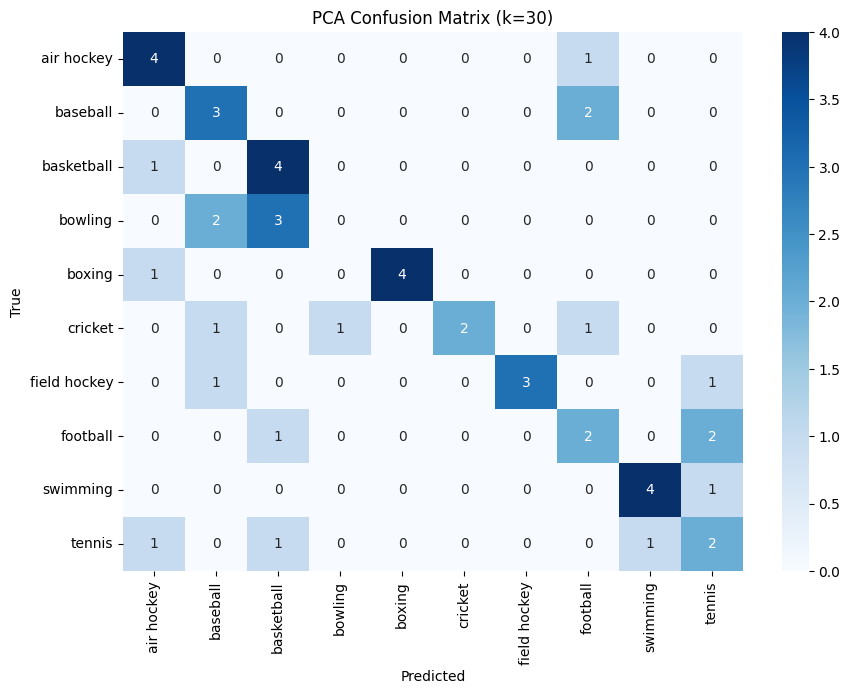

In [29]:
cm = confusion_matrix(y_test,p)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=classnames,yticklabels=classnames)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"PCA Confusion Matrix (k={bestk})")
plt.show()

## Random Test Images with Real and Predicted Values

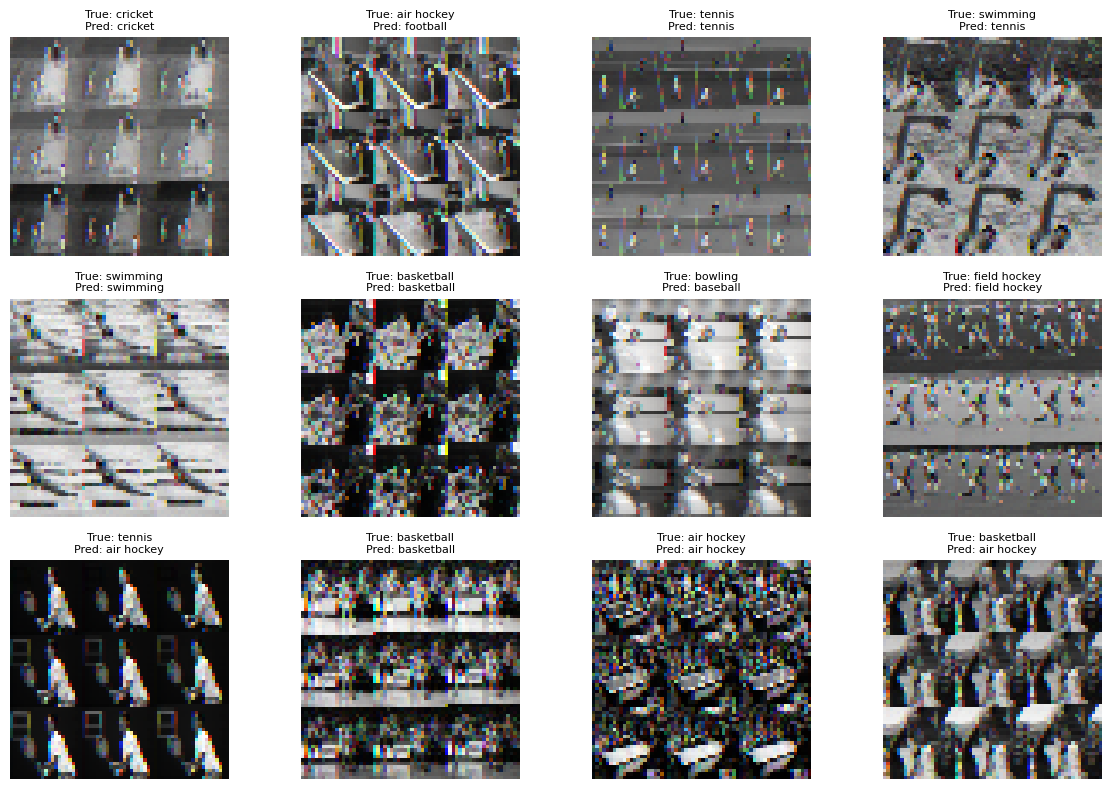

In [ ]:
orig_ids = sorted(list(selected_label_ids))
id_to_idx = {o: i for i, o in enumerate(orig_ids)}
h, w = 64, 64
Xt = X_test.reshape(-1, h, w, 3)
idxs = np.random.choice(len(Xt), size=12, replace=False)
plt.figure(figsize=(12, 8))
for i, j in enumerate(idxs):
    img = Xt[j]
    img_show = np.clip(img * 255, 0, 255).astype("uint8")
    t = int(y_test[j])    
    pr = int(p[j])        
    t_idx = id_to_idx[t]
    p_idx = id_to_idx[pr]
    t_label = classnames[t_idx]
    p_label = classnames[p_idx]
    plt.subplot(3, 4, i + 1)
    plt.imshow(img_show)
    plt.axis("off")
    plt.title(f"True: {t_label}\nPred:{p_label}", fontsize=8)
plt.tight_layout()
plt.show()

## PCA + kNN

## Finding Best K for kNN

In [35]:
from sklearn.neighbors import KNeighborsClassifier
print("\ntraining PCA for k-NN with k =", bestk)
pca_knn = PCA(n_components=bestk)
X_train_knn = pca_knn.fit_transform(X_train)
X_test_knn  = pca_knn.transform(X_test)
ks_knn = [1, 3, 5, 7, 9, 11, 15, 21, 25]
r_knn = {}
for k in ks_knn:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    p_knn = knn.predict(X_test_knn)
    a = accuracy_score(y_test, p_knn)
    f = f1_score(y_test, p_knn, average="macro")
    r_knn[k] = {"a": a, "f": f}
    print("k =", k, "acc =", a, "F1 =", f)
bestknn = max(r_knn, key=lambda j: r_knn[j]["f"])
print("\nbest k for k-NN:", bestknn)
print("best acc:", r_knn[bestknn]["a"])
print("best F1:", r_knn[bestknn]["f"])


training PCA for k-NN with k = 30
k = 1 acc = 0.36 F1 = 0.3272144522144522
k = 3 acc = 0.42 F1 = 0.4066144639674051
k = 5 acc = 0.46 F1 = 0.44261437908496737
k = 7 acc = 0.42 F1 = 0.4093803418803419
k = 9 acc = 0.42 F1 = 0.41378510378510375
k = 11 acc = 0.4 F1 = 0.40249639249639246
k = 15 acc = 0.4 F1 = 0.40017146252440366
k = 21 acc = 0.38 F1 = 0.3885843568196509
k = 25 acc = 0.38 F1 = 0.38717021540550955

best k for k-NN: 5
best acc: 0.46
best F1: 0.44261437908496737


## Training Final k-NN model with 5 Neighbors and PCA = 30

In [ ]:
pca_f=PCA(n_components=bestk)
Xt1 =pca_f.fit_transform(X_train)
Xt2=pca_f.transform(X_test)
knn_f =KNeighborsClassifier(n_neighbors=bestknn)
knn_f.fit(Xt1, y_train)
pf =knn_f.predict(Xt2)
a=accuracy_score(y_test, pf)
f =f1_score(y_test, pf, average="macro")
print("\nfinal k-NN performance")
print("acc =", a)
print("F1  =", f)


final k-NN performance
acc = 0.46
F1  = 0.44261437908496737


## Confusion Matrix for PCA + kNN

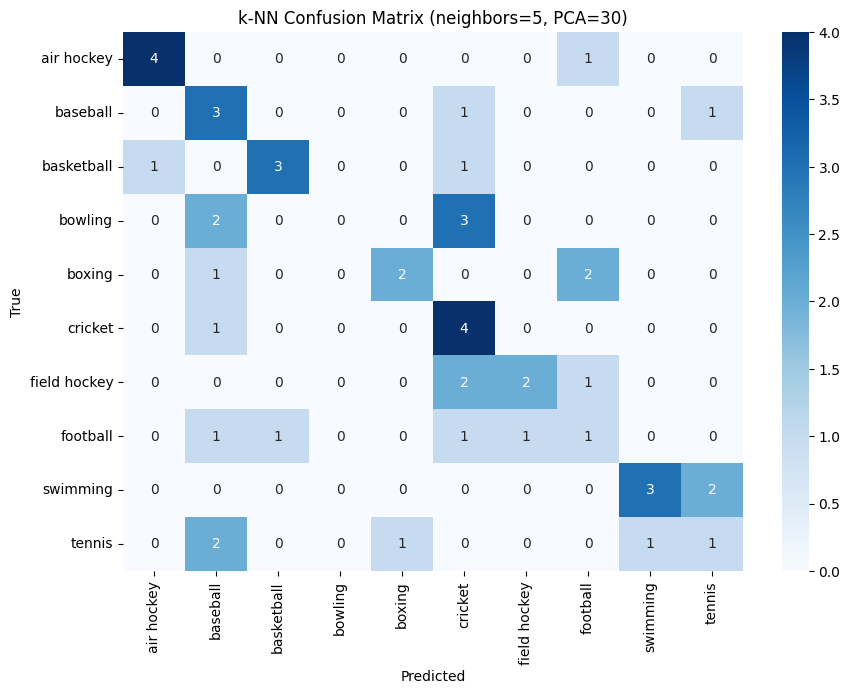

In [41]:
cm_knn= confusion_matrix(y_test,pf)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',xticklabels=classnames,yticklabels=classnames)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"k-NN Confusion Matrix (neighbors={bestknn}, PCA={bestk})")
plt.show()


## Random Test Iaages with Read and Predicted Values 

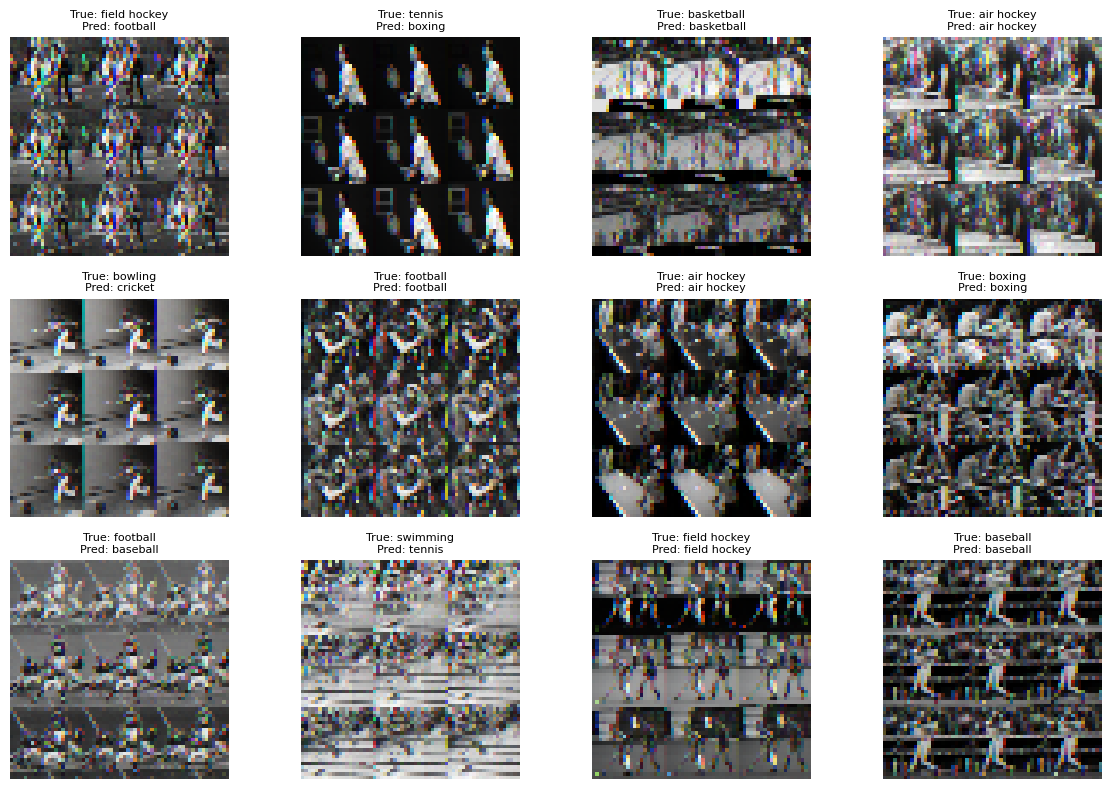

In [40]:
oids = sorted(list(selected_label_ids))
m = {o: i for i, o in enumerate(oids)}
h, w = 64, 64
Xt = X_test.reshape(-1, h, w, 3)
idxs = np.random.choice(len(Xt), size=12, replace=False)
plt.figure(figsize=(12, 8))
for i, j in enumerate(idxs):
    img =Xt[j]
    img_show =np.clip(img * 255, 0, 255).astype("uint8")
    t = int(y_test[j])    
    pr = int(pf[j])        
    t_idx =m[t]
    p_idx =m[pr]
    t_label= classnames[t_idx]
    p_label =classnames[p_idx]
    plt.subplot(3, 4, i + 1)
    plt.imshow(img_show)
    plt.axis("off")
    plt.title(f"True: {t_label}\nPred: {p_label}", fontsize=8)
plt.tight_layout()
plt.show()